In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import networkx as nx
from sklearn.cluster import SpectralClustering
from itertools import combinations

In [13]:
# @title
STATION_ORDER = {

    # ── 1호선 (Line 1) ─────────────────────────────────────────────────────
    # Core trunk: Soyosan → Incheon
    "Line 1": [
        "Soyosan",
        "Dongducheon",
        "Bosan",
        "Dongducheon Jungang",
        "Jihaeng",
        "Deokjeong",
        "Deokgye",
        "Yangju",
        "Nogyang",
        "Ganeung",
        "Uijeongbu",
        "Hoeryong",
        "Mangwolsa",
        "Dobongsan",
        "Dobong",
        "Banghak",
        "Chang-dong",
        "Nokcheon",
        "Wolgye",
        "Kwangwoon Univ.",
        "Seokgye",
        "Sinimun",
        "Hankuk Univ. of Foreign Studies",
        "Hoegi",
        "Cheongnyangni (University of Seoul)",
        "Jegi-dong",
        "Sinseol-dong",
        "Dongmyo",
        "Dongdaemun",
        "Jongno 5(o)-ga",
        "Jongno 3(sam)-ga",
        "Jonggak",
        "City Hall",
        "Seoul Station",
        "Namyeong",
        "Yongsan",
        "Noryangjin",
        "Daebang",
        "Singil",
        "Yeongdeungpo",
        "Sindorim",
        "Guro",
        "Guil",
        "Gaebong",
        "Oryudong",
        "Onsu (Sungkonghoe Univ.)",
        "Yeokgok",
        "Sosa",
        "Bucheon",
        "Jung-dong",
        "Songnae",
        "Bugae",
        "Bupyeong",
        "Baegun",
        "Dongam",
        "Ganseok",
        "Juan",
        "Dohwa",
        "Jemulpo",
        "Dowon",
        "Dongincheon",
        "Incheon",
    ],

    # 경부선 (Gyeongbu Line) — Guro south to Sinchang via Cheonan
    "Gyeongbu Line": [
        "Guro",
        "Gasan Digital Complex",
        "Doksan",
        "Geumcheon-gu Office",
        "Seoksu",
        "Gwanak",
        "Anyang",
        "Myeonghak",
        "Geumjeong",
        "Gunpo",
        "Dangjeong",
        "Uiwang",
        "Sungkyunkwan Univ.",
        "Hwaseo",
        "Suwon",
        "Seryu",
        "Byeongjeom",
        "Sema",
        "Osan Univ.",
        "Osan",
        "Jinwi",
        "Songtan",
        "Seojeong-ri",
        "Pyeongtaek Jije",
        "Pyeongtaek",
        "Seonghwan",
        "Jiksan",
        "Dujeong",
        "Cheonan",
        "Bongmyeong",
        "Ssangyong (Nazareth Univ.)",
        "Asan",
        "Tangjeong",
        "Baebang",
        "Onyang Oncheon",
        "Sinchang (Soonchunhyang Univ.)",
    ],

    # 경원선 (Gyeongwon Line) — Hoegi → Yeoncheon
    # (runs as part of Line 1 through-service)
    "Gyeongwon Line": [
        "Hoegi",
        "Kwangwoon Univ.",
        "Seokgye",
        "Sinimun",
        "Hankuk Univ. of Foreign Studies",
        "Cheongnyangni (University of Seoul)",
        "Jegi-dong",
        "Sinseol-dong",
        "Dongmyo",
        "Dobong",
        "Banghak",
        "Chang-dong",
        "Nokcheon",
        "Wolgye",
        "Mangwolsa",
        "Hoeryong",
        "Uijeongbu",
        "Ganeung",
        "Nogyang",
        "Yangju",
        "Deokgye",
        "Deokjeong",
        "Jihaeng",
        "Dongducheon Jungang",
        "Bosan",
        "Dongducheon",
        "Soyosan",
        "Cheongsan",
        "Jeongok",
        "Yeoncheon",
    ],

    # 경인선 (Gyeongin Line) — mislabeled "Line 1" in CSV; Guro → Incheon
    # NOTE: In the CSV, RouteName=경인선, RouteNameEn='Line 1'
    # Distinguish using the Korean column. Covered by main Line 1 key above,
    # but listed separately here for reference.
    # (No separate key needed if you use Korean RouteName as graph key.)

    # ── 2호선 (Line 2) ─────────────────────────────────────────────────────
    "Line 2": [
        "City Hall",
        "Euljiro 1(il)-ga",
        "Euljiro 3(sam)-ga",
        "Euljiro 4(sa)-ga",
        "Dongdaemun History & Culture Park (DDP)",
        "Sindang",
        "Sangwangsimni",
        "Wangsimni (Seongdong-gu Office)",
        "Hanyang University",
        "Ttukseom",
        "Seongsu",
        "Konkuk Univ",
        "Guui (Gwangjin-gu Office)",
        "Gangbyeon (East Seoul Bus Terminal)",
        "Jamsilnaru",
        "Jamsil (Songpa-gu Office)",
        "Jamsilsaenae",
        "Sports Complex",
        "Samseong (World Trade Center)",
        "Seolleung",
        "Yeoksam",
        "Gangnam",
        "Seoul Nat'l Univ. of Education",
        "Seocho",
        "Bangbae",
        "Sadang",
        "Nakseongdae (Gang Gam-chan)",
        "Seoul Nat'l Univ. (Gwanak-gu Office)",
        "Bongcheon",
        "Sillim",
        "Sindaebang",
        "Guro Digital Complex",
        "Daerim (Guro-gu Office)",
        "Sindorim",
        "Mullae",
        "Yeongdeungpo District Office",
        "Dangsan",
        "Hapjeong",
        "Hongik University",
        "Sinchon",
        "Ewha Womans University",
        "Ahyeon",
        "Chungjeongno (Kyonggi Univ.)",
        # loop continues back to City Hall; branch lines below:
        # Seongsu branch: Seongsu → Sinseol-dong
        "Yongdap",
        "Sindap",
        # Sinjeong branch: Sindorim → Kkachisan
        "Dorimcheon",
        "Yangcheon-gu Office",
        "Sinjeongnegeori",
        "Sinjeong (Bank Area)",
        "Kkachisan",
    ],

    # ── 3호선 (Line 3) ─────────────────────────────────────────────────────
    "Line 3": [
        "Daehwa",
        "Juyeop",
        "Jeongbalsan",
        "Madu",
        "Baekseok",
        "Daegok",
        "Hwajeong",
        "Wondang",
        "Wonheung",
        "Samsong",
        "Jichuk",
        "Gupabal",
        "Yeonsinnae",
        "Bulgwang",
        "Nokbeon",
        "Hongje",
        "Muakjae",
        "Dongnimmun",
        "Gyeongbokgung (Government Complex Seoul)",
        "Anguk",
        "Jongno 3(sam)-ga",
        "Euljiro 3(sam)-ga",
        "Chungmuro",
        "Dongguk Univ",
        "Yaksu",
        "Geumho",
        "Oksu",
        "Apgujeong",
        "Sinsa",
        "Jamwon",
        "Express Bus Terminal",
        "Seoul Nat'l Univ. of Education",
        "Nambu Bus Terminal (Seoul Arts Center)",
        "Yangjae (Seocho-gu Office)",
        "Maebong",
        "Dogok",
        "Daechi",
        "Hangnyeoul",
        "Daecheong",
        "Irwon",
        "Suseo",
        "Garak Market",
        "Police Hospital",
        "Ogeum",
    ],

    # ── 4호선 (Line 4) ─────────────────────────────────────────────────────
    "Line 4": [
        "Danggogae",
        "Sanggye",
        "Nowon",
        "Chang-dong",
        "Ssangmun",
        "Suyu (Gangbuk-gu Office)",
        "Mia (Seoul Cyber University)",
        "Mia Sageori",
        "Gireum",
        "Sungshin Women's Univ. (Donam)",
        "Hansung Univ. (Samseongyo)",
        "Hyehwa",
        "Dongdaemun",
        "Dongdaemun History & Culture Park (DDP)",
        "Chungmuro",
        "Myeong-dong",
        "Hoehyeon (Namdaemun Market)",
        "Seoul Station",
        "Sookmyung Women's Univ. (Galwol)",
        "Samgakji (War Memorial of Korea)",
        "Sinyongsan",
        "Ichon (National Museum of Korea)",
        "Dongjak (National Cemetery)",
        "Chongshin Univ. (Isu)",
        "Sadang",
        "Namtaeryeong",
        "Seonbawi",
        "Seoul Racecourse Park",
        "Seoul Grand Park",
        "Gwacheon",
        "Government Complex Gwacheon",
        "Indeogwon",
        "Pyeongchon",
        "Beomgye",
        "Geumjeong",
        "Sanbon",
        "Surisan",
        "Daeyami",
        "Banwol",
        "Sangnoksu",
        "Hanyang Univ. at Ansan",
        "Jungang",
        "Gojan",
        "Choji",
        "Ansan",
        "Singil Oncheon",
        "Jeongwang",
        "Oido",
    ],

    # ── 5호선 (Line 5) ─────────────────────────────────────────────────────
    "Line 5": [
        "Banghwa",
        "Gaehwasan",
        "Gimpo International Airport",
        "Songjeong",
        "Magok",
        "Balsan",
        "Ujangsan",
        "Hwagok",
        "Kkachisan",
        "Sinjeong (Bank Area)",
        "Mok-dong",
        "Omokgyo (Mokdong Stadium)",
        "Yangpyeong",
        "Yeongdeungpo District Office",
        "Yeongdeungpo Market",
        "Singil",
        "Yeouido",
        "Yeouinaru",
        "Mapo",
        "Gongdeok",
        "Aeogae",
        "Chungjeongno (Kyonggi Univ.)",
        "Seodaemun",
        "Gwanghwamun (Sejong Center)",
        "Jongno 3(sam)-ga",
        "Euljiro 4(sa)-ga",
        "Dongdaemun History & Culture Park (DDP)",
        "Cheonggu",
        "Singeumho",
        "Haengdang",
        "Wangsimni (Seongdong-gu Office)",
        "Majang",
        "Dapsimni",
        "Janghanpyeong",
        "Gunja (Neungdong)",
        "Achasan (Children's Grand Park Rear Gate)",
        "Gwangnaru (Korea Baptist Theological Univ.)",
        "Cheonho (Pungnap Fortress)",
        "Gangdong",
        "Gildong",
        "Gubeundari (Gangdong Community Center)",
        "Myeongil",
        "Godeok",
        "Sangil-dong",
        "Gangil",
        "Misa",
        "Hanam Pungsan",
        "Hanam City Hall (Deokpung–Sinjang)",
        "Hanam Geomdansan",
        # Macheon branch (splits at Gangdong)
        "둔촌동",  # Dunchon-dong
        "Olympia Park (Korea National Sport Univ.)",
        "Bangi",
        "Gaerong",
        "Geoyeo",
        "Macheon",
    ],

    # ── 6호선 (Line 6) ─────────────────────────────────────────────────────
    "Line 6": [
        "Eungam",
        "Yeokchon",
        "Bulgwang",
        "Dokbawi",
        "Yeonsinnae",
        "Gusan",
        "Saejeol (Sinsa)",
        "Jeungsan (Myongji Univ.)",
        "Digital Media City",
        "World Cup Stadium (Seongsan)",
        "Mapo-gu Office",
        "Mangwon",
        "Hapjeong",
        "Sangsu",
        "Gwangheungchang (Sogang Univ.)",
        "Daeheung (Sogang Univ. Front)",
        "Gongdeok",
        "Hyochang Park",
        "Samgakji (War Memorial of Korea)",
        "Noksapyeong (Yongsan District Office)",
        "Itaewon",
        "Hangangjin",
        "Beotigogae",
        "Yaksu",
        "Cheonggu",
        "Sindang",
        "Dongmyo",
        "Changsin",
        "Bomun",
        "Anam (Korea Univ. Hospital)",
        "Korea Univ. (Jongam)",
        "Wolgok (Dongduk Women's Univ.)",
        "Sangwolgok (KIST)",
        "Dolgoji",
        "Seokgye",
        "Taereung Entrance",
        "Hwarangdae (Seoul Women's Univ.)",
        "Bonghwasan (Seoul Medical Center)",
        "Sinnae",
    ],

    # ── 7호선 (Line 7) ─────────────────────────────────────────────────────
    "Line 7": [
        "Jangam",
        "Dobongsan",
        "Suraksan",
        "Madeul",
        "Nowon",
        "Junggye",
        "Hagye",
        "Gongneung (SeoulTech)",
        "Taereung Entrance",
        "Meokgol",
        "Junghwa",
        "Sangbong",
        "Myeonmok",
        "Sagajeong",
        "Yongmasan (Yongma Falls Park)",
        "Junggok",
        "Gunja (Neungdong)",
        "Children's Grand Park (Sejong Univ.)",
        "Konkuk Univ",
        "Jayang (Ttukseom Hangang Park)",
        "Cheongdam",
        "Gangnam-gu Office",
        "Hakdong",
        "Nonhyeon",
        "Banpo",
        "Express Bus Terminal",
        "Naebang",
        "Isu",
        "Namseong",
        "Soongsil Univ. (Salpijae)",
        "Sangdo",
        "Jangseungbaegi",
        "Sindaebangsamgeori",
        "Boramae",
        "Sinpung",
        "Daerim (Guro-gu Office)",
        "Namguro",
        "Gasan Digital Complex",
        "Cheolsan",
        "Gwangmyeong Sageori",
        "Cheonwang",
        "Onsu (Sungkonghoe Univ.)",
        "Bucheon Stadium",
        "Wonjong",
        "Seongnam",
    ],

    # ── 8호선 (Line 8) ─────────────────────────────────────────────────────
    "Line 8": [
        "Amsa Historic Park",
        "Amsa",
        "Cheonho (Pungnap Fortress)",
        "Gangdong-gu Office",
        "Mongchontoseong (Peace Gate)",
        "Jamsil (Songpa-gu Office)",
        "Seokchon",
        "Songpa",
        "Garak Market",
        "Munjeong",
        "Jangji",
        "Bokjeong",
        "Nam Wirye",
        "Sanseong",
        "Namhansanseong Entrance (Seongnam Court & Prosecutors' Office)",
        "Dandae Ogeori",
        "Sinheung",
        "Sujin",
        "Moran",
    ],

    # ── 9호선 (Line 9) ─────────────────────────────────────────────────────
    "Line 9": [
        "Gaehwa",
        "Gimpo International Airport",
        "Airport Market",
        "Sinbanghwa",
        "Magoknaru (Seoul Botanic Park)",
        "Yangcheon Hyanggyo",
        "Gayang",
        "Jeungmi",
        "Deungchon",
        "Yeomchang",
        "Sinmokdong",
        "Seonyudo",
        "Dangsan",
        "National Assembly",
        "Yeouido",
        "Saetgang",
        "Noryangjin",
        "Nodeul",
        "Heukseok (Chung-Ang Univ.)",
        "Dongjak (National Cemetery)",
        "Gubanpo",
        "Sinbanpo",
        "Express Bus Terminal",
        "Sapyeong",
        "Sinnonhyeon",
        "Eonju",
        "Seonjeongneung",
        "Samseong Jungang",
        "Bongeunsa",
        "Sports Complex",
        "Samjeon",
        "Seokchon Ancient Tombs",
        "Seokchon",
        "Songpa Naru",
        "Hanseong Baekje",
        "Olympic Park (Korea National Sport Univ.)",
        "Dunchon Oryun",
        "Central Veterans Hospital",
    ],

    # Line 9 Phase 2-3 is a continuation; merged into Line 9 above.
    "Line 9, Phases 2–3": [
        "Express Bus Terminal",
        "Sapyeong",
        "Sinnonhyeon",
        "Eonju",
        "Seonjeongneung",
        "Samseong Jungang",
        "Bongeunsa",
        "Sports Complex",
        "Samjeon",
        "Seokchon Ancient Tombs",
        "Seokchon",
        "Songpa Naru",
        "Hanseong Baekje",
        "Olympic Park (Korea National Sport Univ.)",
        "Dunchon Oryun",
        "Central Veterans Hospital",
    ],

    # ── 경의선 (Gyeongui Line) ───────────────────────────────────────────────
    # Runs as part of Gyeongui–Jungang through-service; northwest section
    "Gyeongui Line": [
        "Munsan",
        "Imjingang",
        "Uncheon",
        "Paju",
        "Wollong",
        "Geumchon",
        "Geumneung",
        "Unjeong",
        "Yadang",
        "Tanhyeon",
        "Ilsan",
        "Pungsan",
        "Baengma",
        "Goksan",
        "Daegok",
        "Neunggok",
        "Neunggok",
        "Haengsin",
        "Gangmae",
        "Korea Aerospace Univ.",
        "Susaek",
        "Gajwa",
        "Digital Media City",
        "Hongik University",
        "Sogang Univ.",
        "Gongdeok",
        "Yongsan",
        "Seobinggo",
        "Hannam",
        "Oksu",
        "Eungbong",
        "Wangsimni (Seongdong-gu Office)",
        "Hoegi",
    ],

    # ── 경춘선 (Gyeongchun Line) ─────────────────────────────────────────────
    "Gyeongchun Line": [
        "Cheongnyangni (University of Seoul)",
        "Hoegi",
        "Jungnang",
        "Sangbong",
        "Mangu",
        "Sinnae",
        "Galmae",
        "Byeollae",
        "Toegyewon",
        "Sareung",
        "Geumgok",
        "Pyeongnae-Hopyeong",
        "Cheonmasan",
        "Maseok",
        "Daeseong-ri",
        "Cheongpyeong",
        "Sangcheon",
        "Gapyeong",
        "Gulbongsan",
        "Baegyang-ri",
        "Gangchon",
        "Kim Yu-jeong",
        "Namchuncheon",
        "Chuncheon",
    ],

    # ── 분당선 (Bundang Line) / 수인선 (Suin Line) → Suin–Bundang combined ──
    # CSV has separate entries: '분당선' = 'Bundang Line', '수인선' = 'Suin Line'
    "Bundang Line": [
        "Cheongnyangni (University of Seoul)",
        "Wangsimni (Seongdong-gu Office)",
        "Seoul Forest",
        "Apgujeong Rodeo",
        "Gangnam-gu Office",
        "Seonjeongneung",
        "Seolleung",
        "Hanti",
        "Dogok",
        "Guryong",
        "Gaepo-dong",
        "Daemosan Entrance",
        "Suseo",
        "Bokjeong",
        "Gachon Univ.",
        "Taepyeong",
        "Moran",
        "Yatap",
        "Imae",
        "Seohyeon",
        "Sunae",
        "Jeongja",
        "Migeum",
        "Ori",
        "Jukjeon",
        "Bojeong",
        "Guseong",
        "Singal",
        "Giheung",
        "Sanggal",
        "Cheongmyeong",
        "Yeongtong",
        "Mangpo",
        "Maetan-Gwonseon",
        "Suwon City Hall",
        "Maegyo",
        "Suwon",
    ],

    "Suin Line": [
        "Suwon",
        "Gosaek",
        "Omokcheon",
        "Eocheon",
        "Yamok",
        "Sari",
        "Hanyang Univ. at Ansan",
        "Jungang",
        "Gojan",
        "Choji",
        "Ansan",
        "Singil Oncheon",
        "Jeongwang",
        "Oido",
        "Darwol",
        "Wolgot",
        "Soraepogu",
        "Incheon Nonhyeon",
        "Hogupo",
        "Namdong Industrial Park",
        "Woninjae",
        "Yeonsu",
        "Songdo",
        "Inha Univ.",
        "Sungui",
        "Sinpo",
        "Incheon",
    ],

    # ── 공항철도 (Airport Railroad / AREX) ──────────────────────────────────
    "Airport Railroad (AREX)": [
        "Seoul Station",
        "Gongdeok",
        "Hongik University",
        "Digital Media City",
        "Magoknaru (Seoul Botanic Park)",
        "Gimpo International Airport",
        "Gyeyang",
        "Geomam",
        "Cheongna International City",
        "Yeongjong",
        "Unseo",
        "Airport Cargo Terminal",
        "Incheon Airport Terminal 1",
        "Incheon Airport Terminal 2",
    ],

    # ── 경강선 (Gyeonggang Line) ──────────────────────────────────────────
    "Gyeonggang Line": [
        "Pangyo",
        "Imae",
        "Samdong",
        "Gyeonggi Gwangju",
        "Chowol",
        "Gonjiam",
        "Sindun Ceramic Village",
        "Icheon",
        "Bubal",
        "King Sejong's Tomb",
        "Yeoju",
    ],

    # ── 서해선 (Seohae Line) ──────────────────────────────────────────────
    "Seohae Line": [
        "Ilsan",
        "Pungsan",
        "Baengma",
        "Goksan",
        "Daegok",
        "Neunggok",
        "Gimpo International Airport",
        "Wonjong",
        "Bucheon Stadium",
        "Sosa",
        "Bucheon",  # Sosaeul in some references — not in your CSV
        "Sari",
        "Oido",  # southern terminus via Siheung — check CSV exact names
    ],

    # ── 신림선 (Sillim Line) ──────────────────────────────────────────────
    "Sillim Line": [
        "Saetgang",
        "Daebang",
        "Seoul Military Manpower Office",
        "Boramae",
        "Boramae Park",
        "Boramae Medical Center",
        "Danggok",
        "Sillim",
        "Seowon",
        "Seoul Nat'l Univ. Venture Town",
        "Gwanaksan (Seoul Nat'l Univ.)",
    ],

    # ── 안산선 (Ansan Line) — shares track with Line 4 south of Geumjeong ──
    "Ansan Line": [
        "Geumjeong",
        "Sanbon",
        "Surisan",
        "Daeyami",
        "Banwol",
        "Sangnoksu",
        "Hanyang Univ. at Ansan",
        "Jungang",
        "Gojan",
        "Choji",
        "Ansan",
        "Singil Oncheon",
        "Jeongwang",
        "Oido",
    ],

    # ── 과천선 (Gwacheon Line) — shares track with Line 4 ─────────────────
    "Gwacheon Line": [
        "Seoul Station",
        "Sookmyung Women's Univ. (Galwol)",
        "Samgakji (War Memorial of Korea)",
        "Sinyongsan",
        "Ichon (National Museum of Korea)",
        "Dongjak (National Cemetery)",
        "Chongshin Univ. (Isu)",
        "Sadang",
        "Namtaeryeong",
        "Seonbawi",
        "Seoul Racecourse Park",
        "Seoul Grand Park",
        "Gwacheon",
        "Government Complex Gwacheon",
        "Indeogwon",
        "Pyeongchon",
        "Beomgye",
        "Geumjeong",
    ],

    # ── 우이신설선 (Ui-Sinseol Line) ──────────────────────────────────────
    "Ui-Sinseol Line": [
        "Bukhansan Ui",
        "Solbat Park",
        "April 19 National Cemetery",
        "Gaori",
        "Hwagye",
        "Samyang",
        "Samyang Sageori",
        "Solsaem",
        "Bukhansan Bogungmun",
        "Jeongneung",
        "Sungshin Women's Univ.",
        "Bomun",
        "Sinseol-dong",
    ],

    # ── 일산선 (Ilsan Line) — part of Line 3 through service ──────────────
    "Ilsan Line": [
        "Daehwa",
        "Juyeop",
        "Jeongbalsan",
        "Madu",
        "Baekseok",
        "Daegok",
        "Hwajeong",
        "Wondang",
        "Wonheung",
        "Samsong",
        "Jichuk",
        "Gupabal",
        "Yeonsinnae",
        "Bulgwang",
        "Nokbeon",
        "Hongje",
        "Muakjae",
        "Dongnimmun",
        "Gyeongbokgung (Government Complex Seoul)",
        "Anguk",
        "Jongno 3(sam)-ga",
    ],

    # ── 중앙선 (Jungang Line) ─────────────────────────────────────────────
    "Jungang Line": [
        "Yongmun",
        "Wondeok",
        "Obin",
        "Asin",
        "Guksu",
        "Sinwon",
        "Yangsu",
        "Ungilsan",
        "Paldang",
        "Dosim",
        "Deokso",
        "Yangjeong",
        "Donong",
        "Guri",
        "Yangwon",
        "Mangu",
        "Sangbong",
        "Jungnang",
        "Hoegi",
        "Hankuk Univ. of Foreign Studies",
        "Sinimun",
        "Eungbong",
        "Wangsimni (Seongdong-gu Office)",
        "Oksu",
        "Hannam",
        "Seobinggo",
        "Yongsan",
        "Gongdeok",
        "Sogang Univ.",
        "Hongik University",
        "Digital Media City",
        "Susaek",
        "Korea Aerospace Univ.",
        "Gangmae",
        "Haengsin",
        "Neunggok",
        "Daegok",
        "Goksan",
        "Baengma",
        "Pungsan",
        "Ilsan",
        "Tanhyeon",
        "Yadang",
        "Unjeong",
        "Geumneung",
        "Geumchon",
        "Wollong",
        "Paju",
        "Munsan",
        "Imjingang",
        "Jipyeong",
    ],

    # ── 장항선 (Janghang Line) ────────────────────────────────────────────
    "Janghang Line": [
        "Cheonan",
        "Bongmyeong",
        "Ssangyong (Nazareth Univ.)",
        "Asan",
        "Tangjeong",
        "Baebang",
        "Onyang Oncheon",
        "Sinchang (Soonchunhyang Univ.)",
    ],
}

In [9]:
def get_sorted_stations(route_name_en, df_agg):
    """
    Return stations for a given RouteNameEn in correct line order.
    Falls back to original CSV order if line not in STATION_ORDER.
    """
    group = df_agg[df_agg["RouteNameEn"] == route_name_en]["StationNameEn"].tolist()

    if route_name_en not in STATION_ORDER:
        print(f"[WARN] No order defined for '{route_name_en}', using CSV order.")
        return group

    reference = STATION_ORDER[route_name_en]
    ordered = [s for s in reference if s in group]
    missing = [s for s in group if s not in reference]
    if missing:
        print(f"[WARN] {route_name_en}: stations not in reference order: {missing}")
        ordered += missing

    return ordered


def build_graph(xlsx_path: str) -> nx.Graph:
    # ── Load & aggregate ────────────────────────────────────────────────────
    df = pd.read_excel(xlsx_path)
    # Expected columns: Date, RouteName, RouteNameEn, StationName, StationNameEn,
    #                   Boarding, Leaving, RecordedDate
    df.columns = ["Date", "RouteName", "RouteNameEn",
                  "StationName", "StationNameEn",
                  "Boarding", "Leaving", "RecordedDate"]
    df = df.dropna(subset=["RouteNameEn", "StationNameEn"])

    # Sum boarding/leaving across all days in the file
    agg = (df.groupby(["RouteName", "RouteNameEn", "StationNameEn"],
                      as_index=False)[["Boarding", "Leaving"]].sum())

    # ── Build graph ─────────────────────────────────────────────────────────
    G = nx.Graph()

    # Nodes: one per (station, line) pair; boarding+leaving = node weight
    for _, row in agg.iterrows():
        node_id = f"{row['StationNameEn']} [{row['RouteNameEn']}]"
        G.add_node(
            node_id,
            station=row["StationNameEn"],
            line=row["RouteNameEn"],
            route_korean=row["RouteName"],
            boarding=int(row["Boarding"]),
            leaving=int(row["Leaving"]),
            weight=int(row["Boarding"]) + int(row["Leaving"]),  # combined traffic
        )

    # In-line edges: consecutive stations along each line
    for line, group in agg.groupby("RouteNameEn"):
        stations = get_sorted_stations(line, agg)
        for i in range(len(stations) - 1):
            u = f"{stations[i]} [{line}]"
            v = f"{stations[i+1]} [{line}]"
            if G.has_node(u) and G.has_node(v):
                G.add_edge(u, v, type="in_line", line=line)

    # Transfer edges: connect all nodes that share the same station name
    station_nodes = {}
    for node in G.nodes:
        sname = G.nodes[node]["station"]
        station_nodes.setdefault(sname, []).append(node)

    for sname, nodes in station_nodes.items():
        if len(nodes) > 1:
            for u, v in combinations(nodes, 2):
                G.add_edge(u, v, type="transfer")

    return G

In [19]:
def main():
    xlsx_path = "Data_Subway_December.xlsx"
    G = build_graph(xlsx_path)

    print(f"Nodes: {G.number_of_nodes()}")
    print(f"Edges: {G.number_of_edges()}")

    # Example: top 10 stations by combined traffic
    top = sorted(G.nodes(data=True), key=lambda x: x[1]["weight"], reverse=True)[:10]
    for node, data in top:
        print(f"{node}: {data['weight']:,} passengers")

    nx.write_graphml(G, "seoul_subway_graph.graphml")

    return G

Graph = main()

[WARN] Gyeongbu Line: stations not in reference order: ['Daebang', 'Gwangmyeong', 'Namyeong', 'Noryangjin', 'Seodongtan', 'Seoul Station', 'Sindorim', 'Singil', 'Yeongdeungpo', 'Yongsan']
[WARN] Gyeonggang Line: stations not in reference order: ['King Sejong’s Tomb', 'Seongnam']
[WARN] No order defined for 'Gyeongin Line', using CSV order.
[WARN] Gyeongui Line: stations not in reference order: ['Geomam', 'Gimpo International Airport', 'Gyeyang', 'Hyochang Park', 'Seoul Station', 'Sinchon']
[WARN] Gyeongwon Line: stations not in reference order: ['Dobongsan', 'Eungbong', 'Hannam', 'Ichon (National Museum of Korea)', 'Oksu', 'Seobinggo', 'Wangsimni (Seongdong-gu Office)']
[WARN] Jungang Line: stations not in reference order: ['Yangpyeong']
[WARN] Line 2: stations not in reference order: ['Sinseol-dong', 'Yongdu (Dongdaemun-gu Office)']
[WARN] Line 4: stations not in reference order: ['Bulamsan', 'Sookmyung Women’s Univ. (Galwol)', 'Sungshin Women’s Univ. (Donam)']
[WARN] Line 5: stations

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/tmp/ipykernel_347/91991556.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', n_clusters)  # 'tab20' has 20 distinct colors


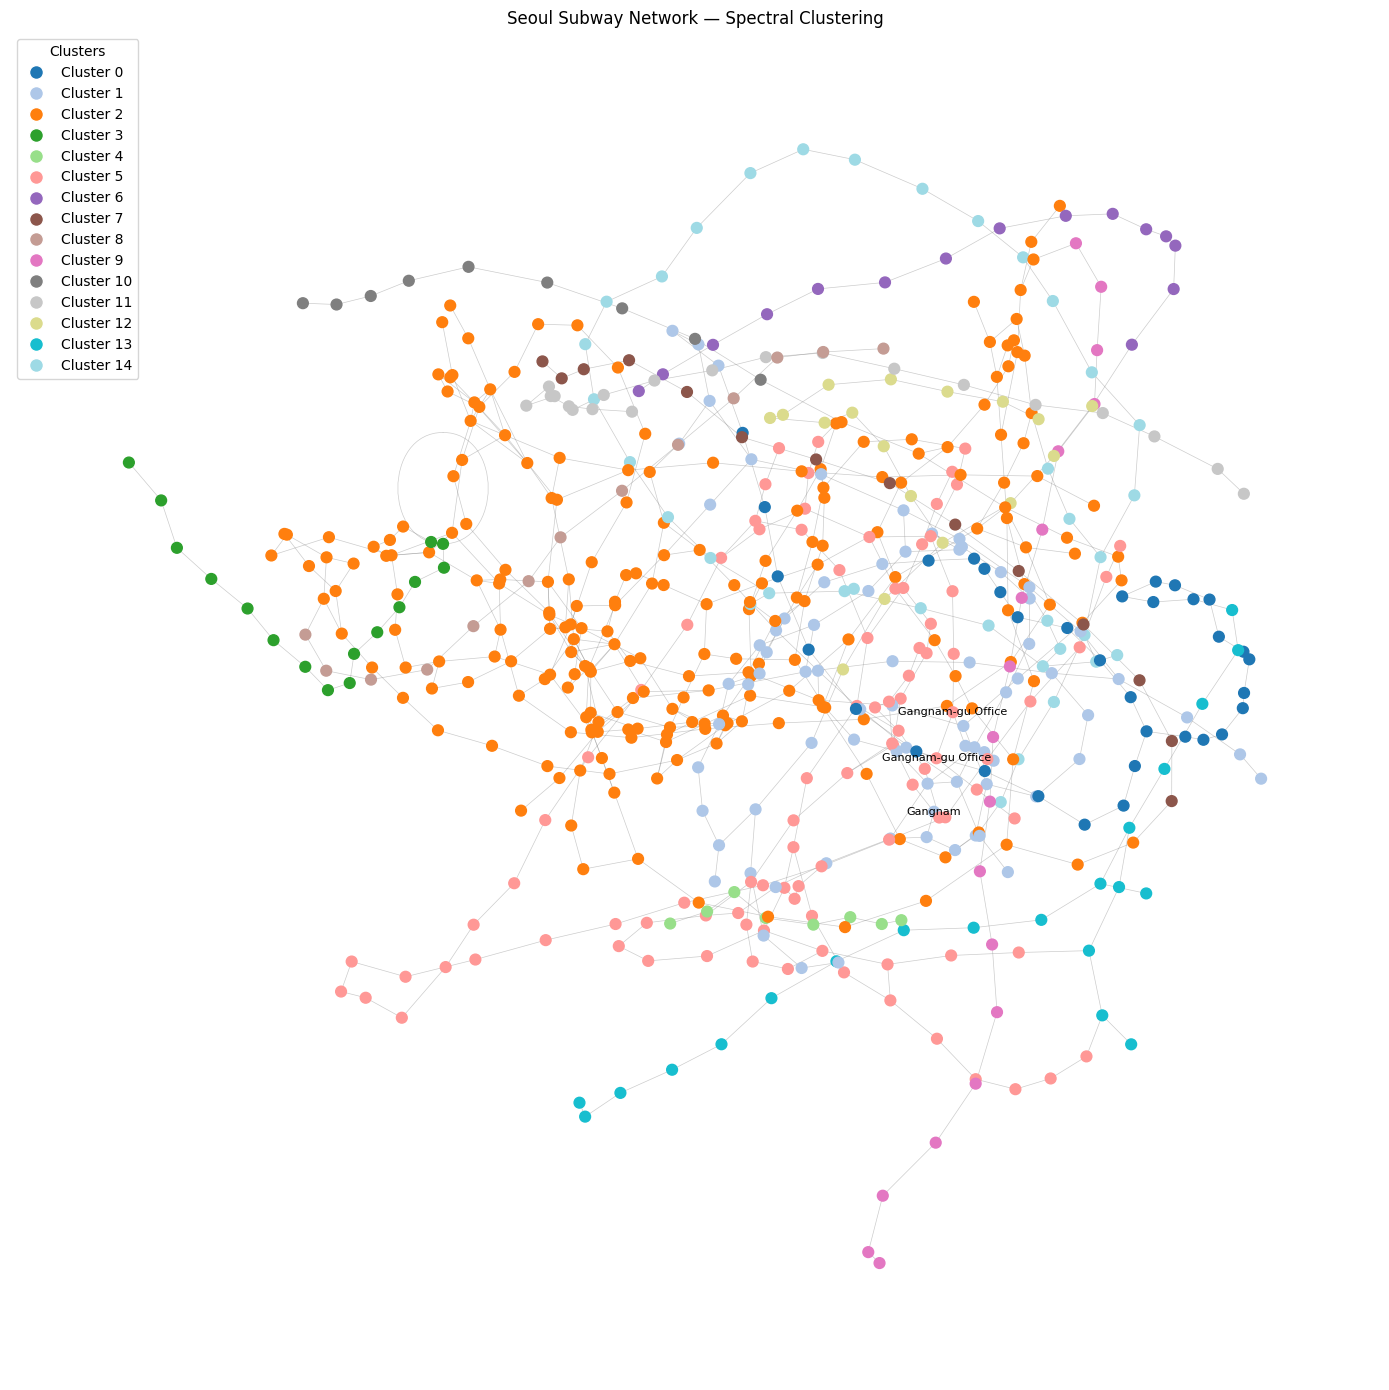

In [26]:
# --- 1. Build adjacency matrix and run spectral clustering ---
A = nx.to_numpy_array(Graph)  # adjacency matrix ordered by G.nodes()

n_clusters = 15  # tune based on laplacian matrix. 4 and 15
sc = SpectralClustering(
    n_clusters=n_clusters,
    affinity='precomputed',
    assign_labels='kmeans',
    random_state=42
)
labels = sc.fit_predict(A)

# Map node -> cluster label
node_list = list(Graph.nodes())
cluster_map = {node: labels[i] for i, node in enumerate(node_list)}

# --- 2. Assign colors per cluster ---
cmap = cm.get_cmap('tab20', n_clusters)  # 'tab20' has 20 distinct colors
node_colors = [cmap(cluster_map[node]) for node in Graph.nodes()]

# --- 3. Draw ---
plt.figure(figsize=(14, 14))
pos = nx.spring_layout(Graph, k=0.15, iterations=20)

# Draw edges first (behind nodes)
nx.draw_networkx_edges(Graph, pos, width=0.5, alpha=0.4, edge_color='gray')

# Draw nodes colored by cluster
nx.draw_networkx_nodes(Graph, pos, node_size=60, node_color=node_colors)

# Labels for notable stations only
node_labels = {
    node: data['station']
    for node, data in Graph.nodes(data=True)
    if len(Graph.nodes) < 100 or 'Gangnam' in data['station']
}
nx.draw_networkx_labels(Graph, pos, labels=node_labels, font_size=8)

# --- 4. Legend ---
handles = [
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor=cmap(i), markersize=10, label=f'Cluster {i}')
    for i in range(n_clusters)
]
plt.legend(handles=handles, title="Clusters", loc='upper left', framealpha=0.8)

plt.title("Seoul Subway Network — Spectral Clustering")
plt.axis('off')
plt.tight_layout()
plt.show()

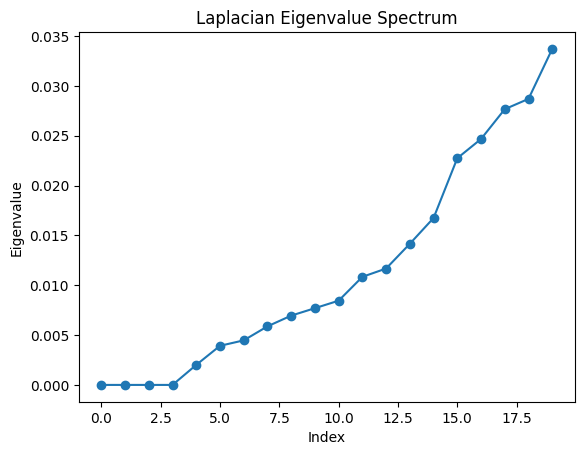

In [21]:
from numpy.linalg import eigvalsh
L = nx.laplacian_matrix(Graph).toarray()
eigenvalues = sorted(eigvalsh(L))
plt.plot(eigenvalues[:20], marker='o')
plt.title("Laplacian Eigenvalue Spectrum")
plt.xlabel("Index"); plt.ylabel("Eigenvalue")
plt.show()